### Основные шаги иследовательского анализа данных

### Шаг 1. Получение общей информации о данных

Bнструменты pandas используeмые для получения общей информации о данных

In [11]:
df.shape # позволит оценить количество строк и столбцов в датафрейме
df.count() # он позволит оценить количество заполненных строк в каждом столбце.
df.head() # выведет на экран пять первых строк датафрейма

NameError: name 'df' is not defined

### Шаг 2. Предобработка данных

На этом шаге нужно поработать с ошибками в данных и подготовить их к последующему анализу: обработать пропущенные значения, явные и неявные дубликаты, скорректировать типы данных.

Работа с пропусками

In [ ]:
fillna() # Используется для замены пропущенных значений в данных
dropna() # используется для удаления пропущенных значений в данных
isna().sum() # Цепочка этих методов позволит посчитать пропуски в датафрейме.

Работа с дубликатами

In [ ]:
drop_duplicates() # удаляет дублирующие строки
duplicated() #  используется для обнаружения дубликатов в датафрейме.

### Шаг 3. Анализ столбцов или данных

Если в столбце представлены числовые данные, то изучают их распределение и основные статистические показатели. Так можно оценить, какие значения наиболее типичны для данных и какой у значений разброс. Можно также выявить аномалии и выбросы в данных, найти возможные ошибки, например нереалистичные значения.
Для этого этапа хорошо подходит визуализация данных с построением гистограмм и диаграмм размаха. Ещё активно используют агрегацию данных с поиском минимального min() и максимального max() значений, а также наиболее типичного значения — среднего mean() или медианы median(). На этом этапе можно изучить результаты метода describe()

Если значения представлены категориями, план действий будет другим: в этом случае нужно проанализировать уникальные категории, выявить их количество и понять, как они распределяются. Здесь работа состоит в том, чтобы проверить корректность написания категорий, найти неявные дубликаты. Для этого данные приводят к одному стилю написания или нормализуют. Нормализация осуществляется с помощью lower(), replace(), strip() и других методов, которые обрабатывают строковые данные.

In [ ]:
nunique() # выведет количество уникальных значений в данных.
unique() # перечислит все уникальные значения в данных
df.value_counts() # позволит получить обзор распределения уникальных значений в столбце и выявить наиболее часто встречающиеся значения.

### Шаг 4. Анализ закономерностей

На этом шаге, как правило, изучают корреляцию данных между собой, строят матрицы распределения значений, изучают тренды изменения показателей во времени, анализируют агрегированные данные и сводные таблицы. Также изучают изменение основных показателей во времени, чтобы зафиксировать возможные сезонные колебания и циклы, которые могут влиять на анализ.
При обнаружении закономерностей в данных могут возникнуть новые гипотезы для проверки. Поэтому часто этот этап включает и формулировку гипотез, которые помогут проверить основной результат анализа.

### Особенности проведения ИАД

* Используйте визуализацию данных. Визуализации помогают изучить данные и найти в них закономерности или ошибки. Аналитики активно используют гистограммы, диаграммы размаха и рассеяния, графики временных рядов и тепловые карты. Все основные типы графиков, которые вы использовали при построении дашбордов, можно использовать и при анализе данных с помощью Python.
* Оценивайте время на проведение ИАД. Исследование данных может занимать много времени — иногда на него уходит больше всего времени и ресурсов. Так происходит, если данные объёмные и содержат множество признаков.
* Уточняйте цели и задачи. Корректно поставленные цели помогают сосредоточиться на ключевых метриках и признаках. Важно понимать зависимости основной метрики от других данных и концентрироваться на целевых признаках.
* Ограничивайте глубину анализа. Исследовательский анализ данных можно вести бесконечно, находя всё новые взаимосвязи и проверяя различные гипотезы. Однако важно избежать ситуации, когда процесс анализа заходит слишком далеко, и вы не можете его завершить. Вместо этого постарайтесь найти золотую середину: сфокусируйтесь на главных целях и задачах и анализируйте данные столько, сколько необходимо, чтобы получить необходимое представление о данных. Фокус на ключевых параметрах позволяет точнее и эффективнее провести исследование данных, сэкономить время и ресурсы и получить полезные результаты.


### ПРАКТИКА!!!

In [12]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix 

In [13]:
# Выгружаем данные в переменные bank_df и clients_df
bank_df = pd.read_csv('bank_information.csv')
clients_df = pd.read_csv('clients_information.csv')

In [14]:
# Выводим первые строки датафрейма на экран
bank_df.head()

,userid,score,Objects,Balance,Products,CreditCard,Loyalty,estimated_salary,Churn
0,15677338,619,2,NaN,1,1,1,101348.88,1
1,15690047,608,1,83807.86,1,0,1,112542.58,0
2,15662040,502,8,159660.80,3,1,0,113931.57,1
3,15744090,699,1,NaN,2,0,0,93826.63,0
4,15780624,850,2,125510.82,1,1,1,79084.10,0


In [15]:
# Выводим информацию о датафрейме
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            10000 non-null  int64  
 1   score             10000 non-null  int64  
 2   Objects           10000 non-null  int64  
 3   Balance           6383 non-null   float64
 4   Products          10000 non-null  int64  
 5   CreditCard        10000 non-null  int64  
 6   Loyalty           10000 non-null  int64  
 7   estimated_salary  10000 non-null  float64
 8   Churn             10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.3 KB


<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;">
После первичного анализа данных можно сделать следующие выводы:
Названия столбцов лучше привести к одному виду, например snake case.
Все представленные данные содержат числовые значения и хранятся в типах данных int64 или float64. Значения в столбцах score, Objects, Products, CreditCard, Loyalty и Churn представлены целыми числами. Часть из них показывает наличие у клиента того или иного признака и содержит значения 1 или 0 — размерность этих данных можно оптимизировать.
Пропуски содержатся только в столбце Balance. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
<div>

In [16]:
# Выводим первые строки датафрейма на экран
clients_df.head()

,userid,LastName,FirstName,Age,Gender,City
0,15677338,Лапина,Евпраксия,42,Ж,Ярославль
1,15690047,Александрова,Акулина,41,Ж,Рыбинск
2,15662040,Лаврентьева,Анна,42,Ж,Ярославль
3,15744090,Никитина,Олимпиада,39,Ж,Ярославль
4,15780624,Некрасова,Майя,43,Ж,Рыбинск


In [17]:
# Выводим информацию о датафрейме
clients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userid     10000 non-null  int64 
 1   LastName   10000 non-null  object
 2   FirstName  10000 non-null  object
 3   Age        10000 non-null  int64 
 4   Gender     10000 non-null  object
 5   City       10000 non-null  object
dtypes: int64(2), object(4)
memory usage: 468.9+ KB


<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;">
Датасет clients_information.csv содержит 6 столбцов и 10000 строк, в которых представлена информация о клиентах банка. По аналогии с предыдущим датасетом можно отметить, что:
Названия столбцов лучше привести к единому виду, например snake case.
Типы данных соответствуют содержимому. Тип данных для столбца Age можно оптимизировать с понижением размерности. Если в столбце нет аномалий, то маловероятно, что он хранит высокие значения.
Пропусков на первый взгляд нет, однако следует проверить в столбцах значения-индикаторы, которые могут говорить об отсутствии данных.
Значения в столбцах соответствуют описанию.
Первичное знакомство показывает, что данные хорошего качества — в них практически нет пропущенных значений, а сами данные соответствуют описанию и выглядят корректными. Настало время следующего этапа — предобработки данных.
<div>

### Предобработка данных

In [18]:
# Выводим названия столбцов датафрейма bank_df
bank_df.columns

Index(['userid', 'score', 'Objects', 'Balance', 'Products', 'CreditCard',
       'Loyalty', 'estimated_salary', 'Churn'],
      dtype='object')

In [19]:
# Передаём методу rename() словарь с названиями столбцов
bank_df = bank_df.rename(columns={'userid': 'userid',
                                  'Objects': 'objects',
                                  'Balance': 'balance',
                                  'Products': 'products',
                                  'CreditCard': 'credit_card',
                                  'Loyalty': 'loyalty',
                                  'Churn': 'churn'})

In [20]:
# Напишем функцию для корректировки названия столбцов из CamelCase в snake_case
def col_to_snake_case(df):
    """
    Функция приводит названия столбцов из CamelCase в snake_case.
    Пример: столбец FirstName станет first_name.
    В качестве аргументов принимает датафрейм.
    Перебирает столбцы и проверяет каждый столбец.
    Если первый символ является заглавной буквой, то он меняется на прописную.
    Если в названии отыскиваются другие заглавные буквы, перед ними вставляется символ
    подчёркивания, и буква меняется на прописную.
    Функция возвращает исправленный датафрейм.
    """

    for col in df.columns:
        str_bad = col
        if str_bad[0].isupper():
            str_bad = str_bad[0].lower() + str_bad[1:]
        for index_s, item_s in enumerate(str_bad):
            if item_s.isupper():
                str_bad = str_bad[:index_s] + '_' + str_bad[index_s].lower() + str_bad[index_s + 1:]
        df = df.rename(columns={col: str_bad})
    return df

In [21]:
# Применяем функцию col_to_snake_case()
clients_df = col_to_snake_case(clients_df)

In [22]:
# Выводим названия столбцов датафрейма clients_df
clients_df.columns

Index(['userid', 'last_name', 'first_name', 'age', 'gender', 'city'], dtype='object')

### Оптимизируем типы данных

С данными банка здесь работы не так много — понадобится только провести оптимизацию целочисленных данных. В целом этот шаг можно было бы пропустить, особенно если данных немного — такое несоответствие не будет ошибкой при обработке данных. Однако для примера оставим этот шаг и проведём оптимизацию целочисленных типов данных.

In [23]:
# Оптимизируем целочисленный тип данных в датафрейме bank_df
for column in ['score','objects','products',
               'credit_card','loyalty','churn']:
    bank_df[column] = pd.to_numeric(bank_df[column],
                                    downcast='integer')

# Оптимизируем целочисленный тип данных в датафрейме clients_df
clients_df['age'] = pd.to_numeric(clients_df['age'], downcast='integer')

### Проверяем наличие пропусков в данных

In [24]:
# Применяем метод isna() к датафрейму bank_df
bank_df.isna().sum()

userid                 0
score                  0
objects                0
balance             3617
products               0
credit_card            0
loyalty                0
estimated_salary       0
churn                  0
dtype: int64

In [25]:
# Подсчитываем долю строк с пропусками
bank_df.isna().sum() / bank_df.shape[0]

userid              0.0000
score               0.0000
objects             0.0000
balance             0.3617
products            0.0000
credit_card         0.0000
loyalty             0.0000
estimated_salary    0.0000
churn               0.0000
dtype: float64

In [26]:
# Определяем функцию, которая создаст новый столбец с бинарным признаком в зависимости от наличия данных в другом столбце
def create_is_na(x):
    """
    Функция создаёт новый столбец с бинарным признаком, который указывает
    на наличие данных в столбце. Функция применяется к столбцу после метода isna()
    """
    if x:
        return 0
    return 1

In [27]:
# Создаём столбец is_balance с помощью функции create_is_na
bank_df['is_balance'] = bank_df['balance'].isna().apply(create_is_na)

После того как столбец-признак is_balance был создан, можно посчитать средние значения или медиану по другим столбцам. Это поможет получить характеристики клиентов с пропуском и без пропуска в столбце balance. Для этого проведём агрегацию данных:
* Для данных с дискретными признаками objects и products будем использовать медиану median. Для таких значений среднее может быть дробным числом, а медиана, как правило, будет числом целым, которое проще интерпретировать.
* Для непрерывных вещественных данных score и estimated_salary используем среднее mean, чтобы охарактеризовать типичное значение.
* Для бинарных данных credit_card, loyalty и churn также используем среднее значение mean — оно будет соответствовать доле значений с признаком 1.

In [28]:
# Проводим агрегацию данных по полю is_balance
bank_df.groupby('is_balance').agg({
    'score':'mean',
    'objects':'median',
    'products':'median',
    'credit_card':'mean',
    'loyalty':'mean',
    'churn':'mean',
    'estimated_salary':'mean'
})

,score,objects,products,credit_card,loyalty,churn,estimated_salary
is_balance,,,,,,,
0,649.452861,5.0,2.0,0.716616,0.517832,0.138236,98983.559549
1,651.138493,5.0,1.0,0.699201,0.513552,0.240796,100717.352956


<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;">
Пропуски в столбце balance, скорее всего, неслучайны и могут зависеть от разных факторов, о которых у нас нет информации. Например, от названия продукта.
<div>

Далее проверим, встречаются ли в данных значения-индикаторы, которые можно рассматривать как пропуски. Иногда для анализа поступают уже частично или полностью подготовленные данные. Если аналитик не знает, по какому алгоритму происходили первичный сбор и обработка данных, лучше дополнительно проверить, использовались ли значения-индикаторы для замены пропусков. Это поможет понять качество данных и избежать ошибок при их агрегации, когда значение-индикатор будет учитываться при расчёте среднего или медианы, что исказит исходные данные.

In [29]:
# Проверяем уникальные значения в столбцах
for column in ['objects', 'products', 'credit_card', 'loyalty', 'churn']:
    print(f'Уникальные значения в столбце {column}:')
    print(bank_df[column].sort_values().unique())
    print()

Уникальные значения в столбце objects:
[ 0  1  2  3  4  5  6  7  8  9 10]

Уникальные значения в столбце products:
[1 2 3 4]

Уникальные значения в столбце credit_card:
[0 1]

Уникальные значения в столбце loyalty:
[0 1]

Уникальные значения в столбце churn:
[0 1]



<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;">
Все значения выглядят корректными. Теперь можно перейти к изучению дубликатов в данных.
<div>

### Явные и неявные дубликаты в данных

In [30]:
# Проверяем полные дубликаты в датафрейме bank_df
bank_df.duplicated().sum()

np.int64(0)

In [31]:
# Проверяем полные дубликаты в датафрейме clients_df
clients_df.duplicated().sum()

np.int64(0)

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по id клиентов должны быть уникальными, то есть каждая строка в данных — уникальный клиент:

In [32]:
# Проверяем неявные дубликаты в датафрейме bank_df
bank_df.duplicated(subset='userid').sum()

np.int64(0)

In [33]:
# Проверяем неявные дубликаты в датафрейме clients_df
clients_df.duplicated(subset='userid').sum()

np.int64(0)

Тут тоже всё хорошо — каждая строка соответствует уникальному клиенту. Теперь проверим корректность написания категориальных значений в данных clients_df.

In [34]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['gender', 'city']:
    print(f'Уникальные значения в столбце {column}:')
    print(clients_df[column].sort_values().unique())
    print()

Уникальные значения в столбце gender:
['Ж' 'М']

Уникальные значения в столбце city:
['Ростов Великий' 'Рыбинск' 'Ярославль']



<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;">

### Промежуточные выводы после предобработки
На этом предобработка завершена. Предоставленные данные хорошего качества и требуют не так много действий по предобработке. Однако, независимо от качества данных, лучше завершить этот этап небольшим промежуточным выводом: отметить основные действия и ошибки, с которыми вы столкнулись на этом шаге.
В результате предобработки данных были выполнены следующие действия:
Скорректированы названия столбцов — их привели к стилю snake case;
Изучены пропуски в данных. Пропуски обнаружились в столбце balance и составляют около 36% данных столбца. Учитывая это количество, пропуски могут отражать особенности использования услуг клиентами и не являться ошибкой в данных. Поэтому их оставили как есть.
Данные проверили на явные и неявные дубликаты — в данных их нет.
<div>

### Соединяем данные в единый датафрейм
Данные, которые изучают аналитики, часто находятся в разных таблицах базы данных или датасетах. Вы уже сталкивались с этим, например, в проектах по SQL, когда вы присоединяли данные из одной таблицы к другой.
В pandas также бывают разные случаи: иногда анализ данных удобнее провести на объединённых данных, а иногда — на разрозненных. Задача этого спринта предполагает создание портрета клиента для анализа его лояльности. Поэтому можно соединить данные о том, как клиент пользуется банковскими продуктами из таблицы bank_df, с персональными данными — возрастом и городом проживания из таблицы clients_df.

In [35]:
# Соединяем данные в единый датафрейм df
df = bank_df.merge(clients_df, on='userid')

In [36]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            10000 non-null  int64  
 1   score             10000 non-null  int16  
 2   objects           10000 non-null  int8   
 3   balance           6383 non-null   float64
 4   products          10000 non-null  int8   
 5   credit_card       10000 non-null  int8   
 6   loyalty           10000 non-null  int8   
 7   estimated_salary  10000 non-null  float64
 8   churn             10000 non-null  int8   
 9   is_balance        10000 non-null  int64  
 10  last_name         10000 non-null  object 
 11  first_name        10000 non-null  object 
 12  age               10000 non-null  int8   
 13  gender            10000 non-null  object 
 14  city              10000 non-null  object 
dtypes: float64(2), int16(1), int64(2), int8(6), object(4)
memory usage: 703.3+ KB


### Изучаем значения в столбцах
Исследовательский анализ данных, как правило, начинается с последовательного изучения значений в каждом столбце. При этом выбор инструмента для исследования зависит от данных.
Напомним, что по своему типу данные можно разделить на числовые и категориальные. Числовые данные обычно содержат целочисленные или вещественные значения. Они могут быть непрерывными, как, например, средний заработок клиента, или дискретными, которые представлены целочисленными данными и могут иметь ограничения, как количество продуктов банка. В последнем случае значения не могут быть отрицательными или дробными, а максимальное значение ограничено общим количеством продуктов в банке.
Категориальные данные содержат названия категорий, к которым принадлежит та или иная строка. Например, город первого обращения клиента в банк. К категориальным данным можно отнести и данные с бинарным признаком. Например, информацию о том, участвует ли клиент в программе лояльности.
Теперь о способах исследования: в случае категориальных данных можно изучать распределение клиентов по категориям, а непрерывные числовые данные оценивать по распределению значений и выбросам с помощью гистограмм и диаграмм размаха (они же «ящики с усами»).

Сначала разберём столбец objects, который хранит целочисленные дискретные значения. Количество уникальных значений в нём невелико — от 0 до 10. Это мы узнали на этапе предобработки данных.
Для изучения таких данных можно использовать метод value_counts(). Как вы уже знаете, этот метод помогает увидеть распределение данных, то есть строк, по уникальным значениям в столбце. В нашем случае каждая строка данных — уникальный клиент, поэтому метод позволит оценить распределение клиентов по количеству объектов собственности.

In [37]:
# Проверяем распределение данных по значениям столбца objects
print('Распределение данных по значениям столбца objects:')
df['objects'].value_counts()

Распределение данных по значениям столбца objects:


objects
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;"> 
По этим данным можно сделать вывод, что все значения в этом столбце примерно сопоставимы по количеству данных, за исключением двух категорий, где данных в два раза меньше (0 и 10 объектов). Это стоит учитывать при сравнении статистических показателей разных категорий.
<div>

Для анализа данных в таких столбцах можно использовать группировку по уникальному значению с подсчётом определённых параметров, например уникальных идентификаторов клиентов или среднего значения баланса. Узнаем уникальное количество клиентов по значениям столбца objects:

In [38]:
# Посчитаем количество уникальных клиентов для каждого значения столбца objects
print('Распределение клиентов по значениям столбца objects:')
df.groupby('objects')['userid'].nunique()

Распределение клиентов по значениям столбца objects:


objects
0      413
1     1035
2     1048
3     1009
4      989
5     1012
6      967
7     1028
8     1025
9      984
10     490
Name: userid, dtype: int64

In [39]:
# Проверяем распределение данных по значениям столбца products
print('Распределение данных по значениям столбца products:')
df['products'].value_counts()

Распределение данных по значениям столбца products:


products
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;"> 
Клиенты в основном предпочитают один или два продукта, и общее количество клиентов в этих категориях представлено близкими значениями. А вот тремя и четырьмя продуктами пользуется гораздо меньше людей. Это значит, что клиенты распределены неравномерно между количеством продуктов, и это накладывает свои ограничения на сравнение групп между собой.
<div>

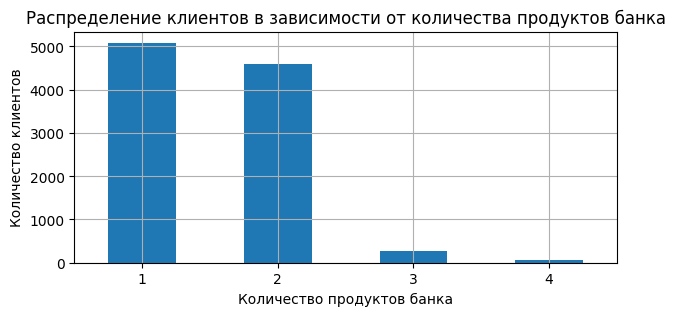

In [40]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['products'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от количества продуктов банка'
)

# Настраиваем оформление графика
plt.xlabel('Количество продуктов банка')
plt.ylabel('Количество клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

### Непрерывные числовые данные

Теперь посмотрим на данные кредитного рейтинга клиента score и его баланса на счёте balance. Значения в них относятся к непрерывным вещественным данным.
Начнём с баланса — при знакомстве с подобными данными вначале стоит оценить статистические показатели. Для этого используем метод describe()

In [41]:
# Изучаем статистические показатели столбца balance
print('Статистические показатели столбца balance:')
df['balance'].describe()


Статистические показатели столбца balance:


count      6383.000000
mean     119827.493793
std       30095.056462
min        3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
max      250898.090000
Name: balance, dtype: float64

<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;">
Можно предположить, что данные баланса имеют распределение, близкое к нормальному. Об этом говорит близость среднего и медианного значений. Однако значение стандартного отклонения довольно высокое — 30095.06, и при среднем 119827.49 это указывает, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает.
<div>

Дополнительно проверим это и построим гистограмму распределения значений и диаграмму размаха для столбца с балансом.

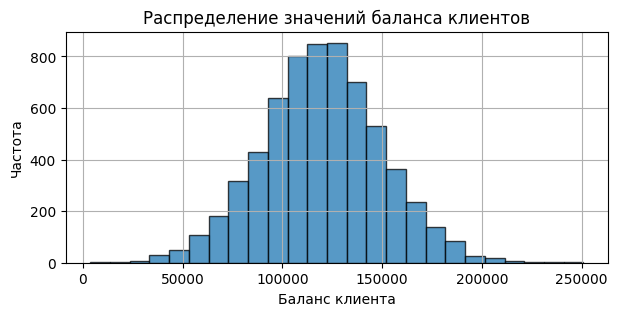

In [42]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['balance'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений баланса клиентов')
plt.xlabel('Баланс клиента')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

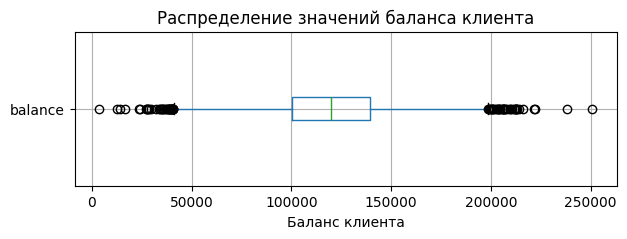

In [43]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='balance', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений баланса клиента')
plt.xlabel('Баланс клиента')

# Выводим график
plt.show()

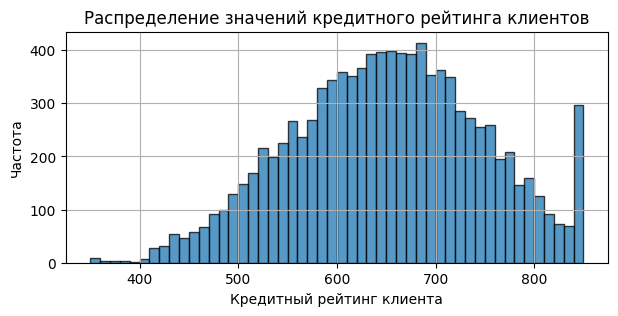

In [44]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['score'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 50
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений кредитного рейтинга клиентов')
plt.xlabel('Кредитный рейтинг клиента')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Проверим эту особенность данных отдельно и изучим распределение данных для значений рейтинга от 840 до 850:



In [45]:
# Проверяем распределение данных по значениям столбца score 840 и выше
print('Распределение данных по значениям столбца score 840 и выше:')
df.loc[df['score'] >= 840]['score'].value_counts()

Распределение данных по значениям столбца score 840 и выше:


score
850    233
841     12
849      8
844      7
842      7
847      6
845      6
840      5
846      5
848      5
843      2
Name: count, dtype: int64

### Бинарные признаки и категориальные данные

Изучение бинарных признаков и категориальных данных похоже на изучение дискретных числовых данных с небольшим количеством значений. Для бинарных признаков важно оценить, как распределяются клиенты между признаками, а для категориальных данных — убедиться, что в них нет ошибок, а также проверить распределение значений по категориям.
При исследовании таких данных можно использовать метод value_counts() с аргументом normalize=True, чтобы сравнить доли значений. Изучим значения в столбцах с бинарными признаками, применив метод value_counts() для каждого столбца в цикле:

In [46]:
# Проверяем распределение данных по значениям в столбце
for column in ['credit_card','loyalty','churn']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts(normalize=True))
    print()

Распределение данных по значениям столбца credit_card:
credit_card
1    0.7055
0    0.2945
Name: proportion, dtype: float64

Распределение данных по значениям столбца loyalty:
loyalty
1    0.5151
0    0.4849
Name: proportion, dtype: float64

Распределение данных по значениям столбца churn:
churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64



<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;"> 
Доля нелояльных клиентов, которые покинули банк, из столбца churn составляет около 20%, а доля клиентов без кредитных карт из столбца credit_card — около 30%. Распределение данных по уникальным значениям столбца loyalty примерно равно — 51% к 49%. Так соотносятся клиенты, которые участвуют в программах лояльности банка, с теми, кто предпочитает в них не участвовать.
<div>

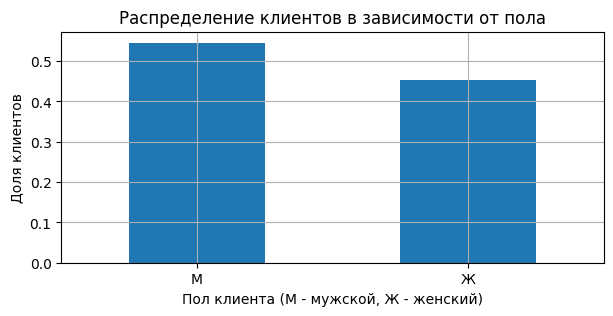

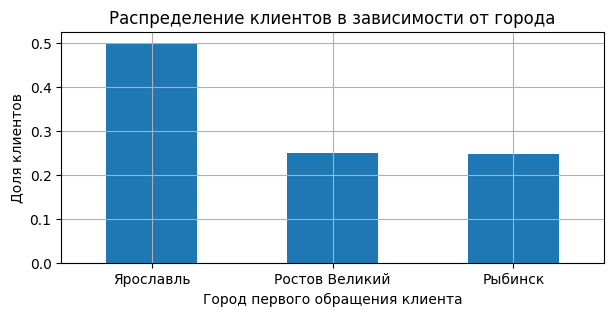

In [47]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['gender'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика — столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от пола'
)

# Настраиваем оформление графика
plt.xlabel('Пол клиента (М - мужской, Ж - женский)')
plt.ylabel('Доля клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['city'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от города'
)

# Настраиваем оформление графика
plt.xlabel('Город первого обращения клиента')
plt.ylabel('Доля клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

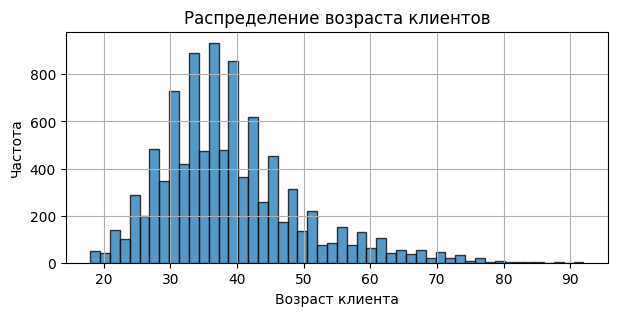

In [48]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['age'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 50
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст клиента')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;"> 
Большенство клиентов банка в возрасте от 30 до 45 лет, причем смещение имеется в сторону с большим возрастом, что указывает на небольшие но имеющиеся значения возрастных клиентов.
<div>

### Изучение корреляции между данными

In [49]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['objects', 'products', 'balance', 'estimated_salary', 'score',
                         'credit_card', 'loyalty', 'is_balance', 'age',
                         'gender', 'city', 'churn']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной churn')
correlation_matrix.loc[correlation_matrix.index != 'churn'][['churn']].sort_values(by='churn', ascending=False)

interval columns not set, guessing: ['objects', 'products', 'balance', 'estimated_salary', 'score', 'credit_card', 'loyalty', 'is_balance', 'age', 'churn']
Корреляционная матрица с коэффициентом phi_k для переменной churn


,churn
products,0.565084
age,0.487170
loyalty,0.241939
is_balance,0.189997
gender,0.165422
balance,0.116624
score,0.112267
city,0.104511
objects,0.028707
credit_card,0.000000


<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;"> 
Обобщим, что показывают результаты: наибольшая корреляция оттока клиентов наблюдается с количеством продуктов (0.57), возрастом клиента (0.49) и участием в программах лояльности (0.24). Для остальных признаков коэффициент корреляции снижается с 0.19 до 0.
<div>

Перед тем как перейти к дальнейшему анализу, визуализируем результат корреляции с помощью тепловой карты и библиотеки seaborn

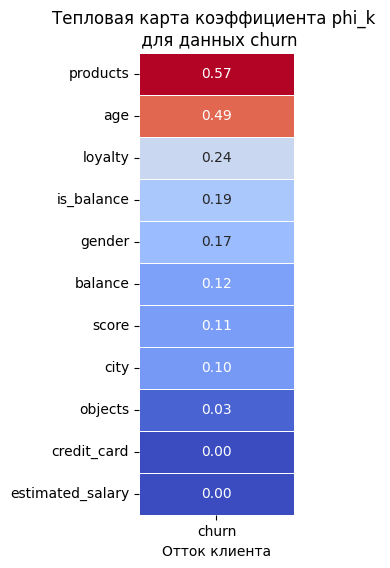

In [50]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'churn'][['churn']].sort_values(by='churn', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных churn')
plt.xlabel('Отток клиента')

# Выводим график
plt.show()

### Анализ взаимосвязей между данными

Изучим, существует ли зависимость между уходом клиента из банка и городом первого обращения. Для этого построим столбчатые диаграммы с разделением по признаку churn среди разных городов:

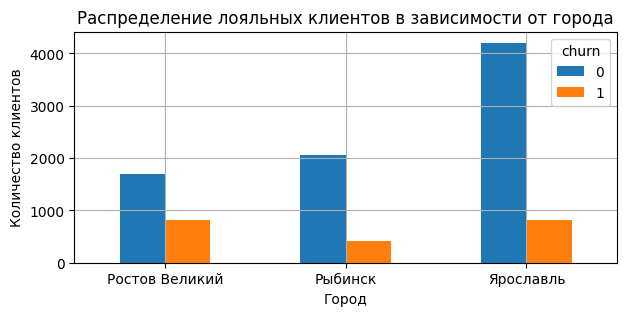

In [51]:
# Построим график столбчатой диаграммы
grouped = df.groupby('city')['churn'].value_counts().unstack(fill_value=0)
grouped.plot(kind='bar',
               title=f'Распределение лояльных клиентов в зависимости от города',
               legend=True,
               ylabel='Количество клиентов',
               xlabel='Город',
               rot=0,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

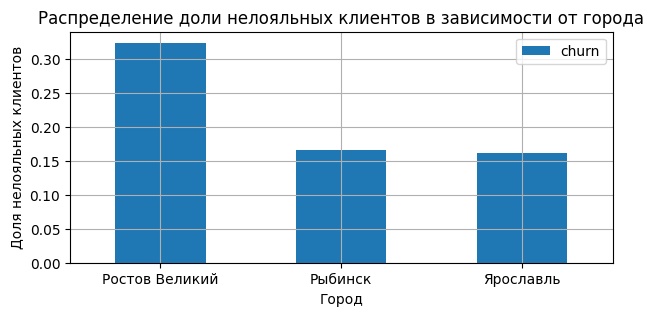

In [52]:
# Построим график столбчатой диаграммы
grouped = df.groupby('city')['churn'].mean()
grouped.plot(kind='bar',
               title=f'Распределение доли нелояльных клиентов в зависимости от города',
               legend=True,
               ylabel='Доля нелояльных клиентов',
               xlabel='Город',
               rot=0,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

Добавим на график линию, которая будет показывать среднее значение. Чтобы на график matplotlib добавить горизонтальную линию, можно использовать метод axhline() — в качестве первого аргумента он принимает значение по оси Y, по которому будет строиться горизонтальная линия. Можно использовать и другие параметры matplotlib, которые зададут оформление линии:

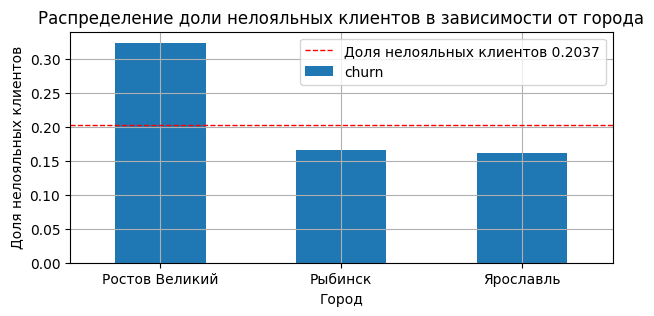

In [53]:
# Строим график столбчатой диаграммы
grouped = df.groupby('city')['churn'].mean()
grouped.plot(kind='bar',
               title=f'Распределение доли нелояльных клиентов в зависимости от города',
               legend=True,
               ylabel='Доля нелояльных клиентов',
               xlabel='Город',
               rot=0,
               figsize=(7, 3))

# Рассчитываем среднее значение по доле нелояльных клиентов
mean_churn_share = df['churn'].mean()

# Наносим на график линию со средним значением доли нелояльных клиентов
plt.axhline(mean_churn_share, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Доля нелояльных клиентов {round(mean_churn_share,4)}')

plt.grid()
plt.legend()

# Выводим график
plt.show()

In [54]:
# Задаём функцию для анализа данных
def plot_bar_plot(df, groupby, value, aggfunc, title, ylabel, xlabel):
    '''
    Функция для анализа распределения метрики по признакам:
    df - датафрейм с данными для анализа;
    groupby - str, название столбца для группировки данных;
    value - str, название столбца, значение которого будет агрегироваться;
    aggfunc - str, функция агрегации, которая используется для расчёта;
    title - str, заголовок графика;
    ylabel - str, подпись по оси Y;
    xlabel - str, подпись по оси X.
    '''
    grouped = df.groupby(groupby).agg({value:aggfunc})
    grouped.plot(kind='bar',
                   title=title,
                   legend=True,
                   ylabel=ylabel,
                   xlabel=xlabel,
                   rot=0,
                   figsize=(7, 3))

    # Рассчитываем общее значение value по всем данным
    mean_churn_share = df.agg({value:aggfunc}).iloc[0]

    # Наносим на график линию с значением value по всем данным
    plt.axhline(mean_churn_share, color='red',
                linestyle='--', linewidth=1,
                label=f'Значение по всем данным {round(mean_churn_share,4)}')

    plt.grid()
    plt.legend()
    plt.show()

Применим функцию и изучим распределение доли нелояльных клиентов в зависимости от количества объектов собственности.

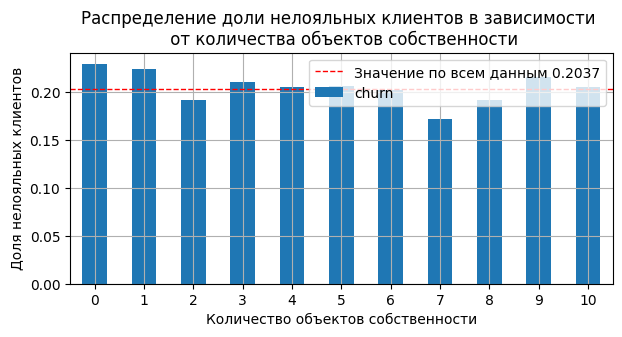

In [55]:
title='Распределение доли нелояльных клиентов в зависимости \n от количества объектов собственности'
xlabel='Количество объектов собственности'
ylabel='Доля нелояльных клиентов'

plot_bar_plot(df, 'objects', 'churn', 'mean', title, ylabel, xlabel)

<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;"> 
Видно, что нет чёткой зависимости между увеличением количества объектов собственности и изменением доли нелояльных клиентов. Значения находятся примерно около среднего, однако можно отметить тенденцию, что клиенты без объектов или с одним объектом собственности более склонны к оттоку.
<div>

Снова применим функцию и изучим распределение доли нелояльных клиентов в зависимости от пола клиентов.

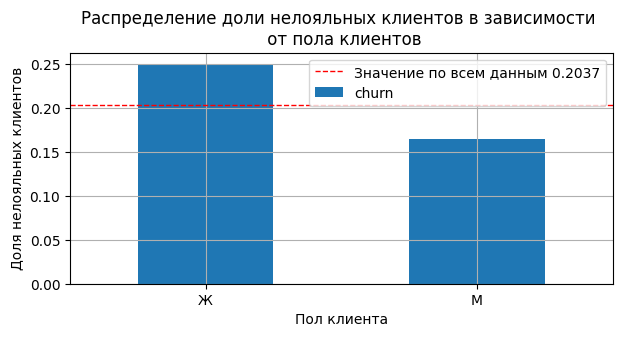

In [56]:
title='Распределение доли нелояльных клиентов в зависимости \n от пола клиентов'
xlabel='Пол клиента'
ylabel='Доля нелояльных клиентов'

plot_bar_plot(df, 'gender', 'churn', 'mean', title, ylabel, xlabel)

<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;"> 
Из графика видно что отток больше среди женьщин и составляет 25% при средих 20 %.
<div>

Применим функцию для изучения доли лояльных клиентов в зависимости от наличия кредитной карты

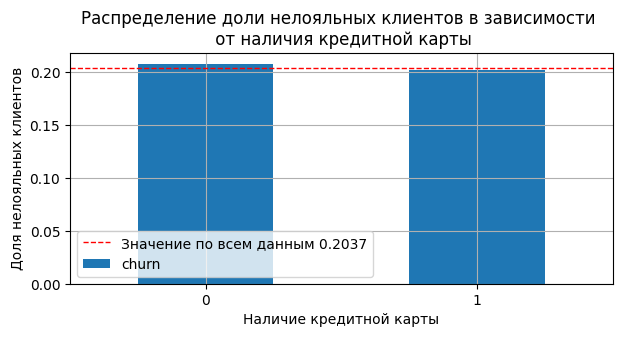

In [57]:
title='Распределение доли нелояльных клиентов в зависимости \n от наличия кредитной карты'
xlabel='Наличие кредитной карты'
ylabel='Доля нелояльных клиентов'

plot_bar_plot(df, 'credit_card', 'churn', 'mean', title, ylabel, xlabel)

<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;"> 
Как видно из графика от наличия кредитной карты практически не зависит лояльность клиентов
<div>

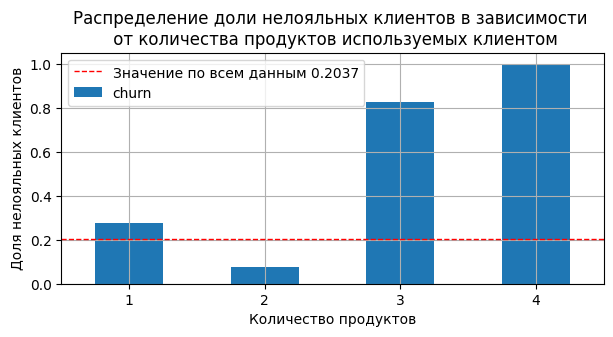

In [58]:
title='Распределение доли нелояльных клиентов в зависимости \n от количества продуктов используемых клиентом'
xlabel='Количество продуктов'
ylabel='Доля нелояльных клиентов'

plot_bar_plot(df, 'products', 'churn', 'mean', title, ylabel, xlabel)

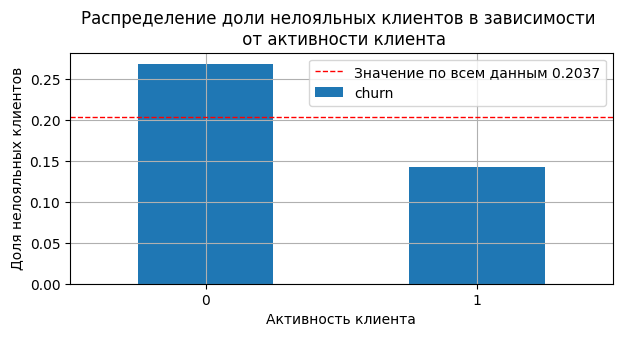

In [59]:
title='Распределение доли нелояльных клиентов в зависимости \n от активности клиента'
xlabel='Активность клиента'
ylabel='Доля нелояльных клиентов'

plot_bar_plot(df, 'loyalty', 'churn', 'mean', title, ylabel, xlabel)

### Изучаем числовые непрерывные данные

Теперь перейдём к непрерывным числовым данным и изучим гистограммы распределения возраста в разрезе лояльных и нелояльных клиентов. У клиента может быть два признака лояльности: он либо ушёл из банка, либо нет. Поэтому в matplotlib необходимо построить два графика по разным значениям признака churn. Удобно это сделать в цикле, который будет строить два графика в зависимости от churn. Чтобы не прописывать значение churn вручную, используем метод unique() для определения уникальных значений:

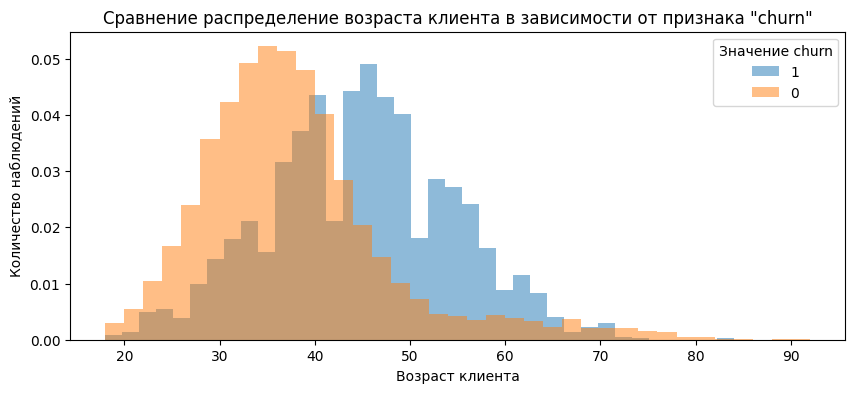

In [60]:
# Строим гистограмму распределения значений возраста
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in df['churn'].unique():
    # Фильтруем данные по значению столбца churn
    df.loc[df['churn'] == i, 'age'].plot(
        kind='hist',
        bins=37,
        density=True, # плотность распределения
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение распределение возраста клиента в зависимости от признака "churn"')
plt.xlabel('Возраст клиента')
plt.ylabel('Количество наблюдений')
plt.legend(title='Значение churn')
plt.show()

Значение параметра bins пропишем как интервал от минимального к максимальному значению с шагом 2: bins=range(min_value, max_value+1, 2). Здесь +1 нужно для того, чтобы увеличить интервал значений, ведь функция range() не использует последнее значение в интервале:



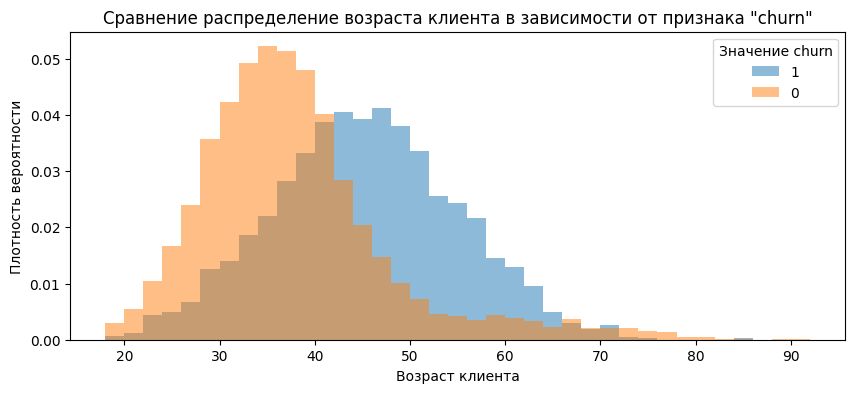

In [61]:
# Строим гистограмму распределения значений возраста
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Находим минимальное и максимальное значения
min_value = df['age'].min()
max_value = df['age'].max()

# Строим гистограммы для каждого значения churn
for i in df['churn'].unique():
    # Фильтруем данные по значению столбца churn
    df.loc[df['churn'] == i, 'age'].plot(
        kind='hist',
        density=True,
        bins=range(min_value, max_value+1, 2),
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение распределение возраста клиента в зависимости от признака "churn"')
plt.xlabel('Возраст клиента')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значение churn')

plt.show()

<div style="background-color: #007bff; color: white; padding: 15px; border-radius: 5px;"> 
Переведём с языка графика: услугами банка предпочитает пользоваться более молодое поколение клиентов возраста от 30 до 40 лет. Эти результаты согласуются с высоким коэффициентом корреляции phi_k — 0.49. Теперь мы можем более точно сказать, что с повышением возраста клиент более склонен к оттоку.
<div>

Дополнительно вместо гистограммы можно использовать график KDE — оценку функции плотности вероятности для непрерывных данных. KDE представляет гладкую линию, которая показывает вероятность встретить значения в определённом диапазоне. Чем выше линия располагается на графике, тем больше вероятность встретить подобное значение. Сравнение линий KDE двух распределений помогает выявить различия между ними.

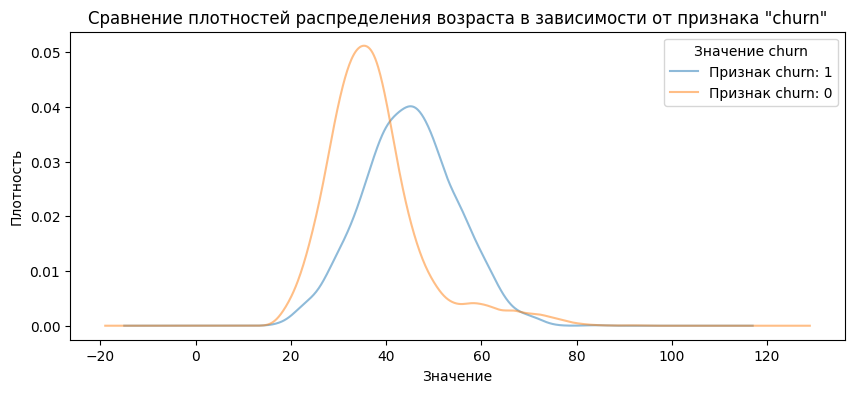

In [62]:
# Строим гистограмму распределения значений возраста
column = 'age'

# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in df['churn'].unique():
    # Фильтруем данные по значению столбца churn
    df.loc[df['churn'] == i, column].plot(
        kind='kde',
        alpha=0.5,
        label=f'Признак churn: {i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение плотностей распределения возраста в зависимости от признака "churn"')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend(title='Значение churn')
plt.show()

Для более детального анализа данных рассчитаем среднее и медианное значения возраста для лояльных и нелояльных клиентов

In [63]:
# Рассчитаем среднее и медианное значения возраста для
# лояльных и нелояльных клиентов
df.groupby('churn').agg({'age':['mean','median']})

age       
            mean median
churn                  
0      37.408389   36.0
1      44.837997   45.0

На основе написанного кода создадим функцию для визуализации данных:

In [64]:
def plot_hist(df, column, groupby, title, xlabel, ylabel, binwidth, kde=False):
    '''
    Функция для визуализации распределения значений с учётом категорий и линией KDE.
    Параметры:
    df - датафрейм с данными для анализа.
    column - str, название столбца, значения которого будут отображаться на графике.
    groupby - str, название столбца, по которому будет производиться группировка данных.
    binwidth - int, ширина корзины для гистограммы.
    title - str, заголовок графика.
    xlabel - str, подпись по оси X.
    ylabel - str, подпись по оси Y.
    kde - наложение графика KDE на гистограмму
    '''

    # Создаём график
    plt.figure(figsize=(7, 3))

    # Находим минимальное и максимальное значения
    min_value = int(df[column].min())
    max_value = round(df[column].max())

    for value in df[groupby].unique():
        # Фильтруем данные по значению столбца churn
        df.loc[df[groupby] == value, column].plot(
            kind='hist',
            density=True,
            bins=range(min_value, max_value+1, binwidth),
            alpha=0.5,
            label=f'{groupby}: {value}',
            legend=True
        )

    for value in df[groupby].unique():
        if kde == True:
            df.loc[df[groupby] == value, column].plot(
                kind='kde',
                label=f'KDE {value}',
            )

    # Настраиваем график
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.xlim(min_value, max_value)

    plt.grid()
    plt.show()

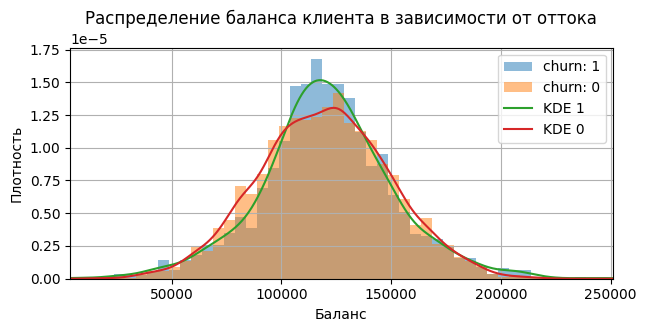

In [65]:
# Изучаем распределение значений баланса клиентов в зависимости от их лояльности
plot_hist(
    df=df,
    column='balance',
    groupby='churn',
    binwidth=5000,
    title='Распределение баланса клиента в зависимости от оттока',
    xlabel='Баланс',
    ylabel='Плотность',
    kde=True
)

<div style="background-color: #5900ff; color: white; padding: 15px; border-radius: 5px;"> 
Распределение значений баланса лояльных и нелояльных клиентов примерно равно. Предполагаем, что баланс вряд ли играет определяющую роль при уходе клиента из банка.
<div>

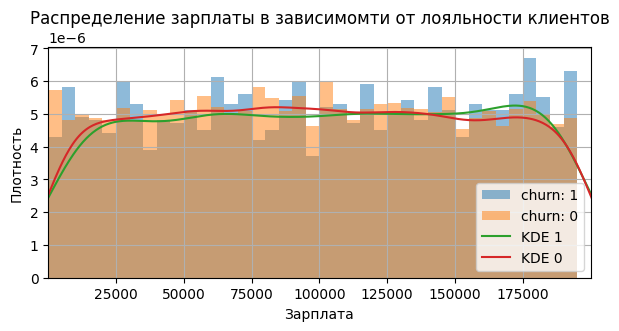

In [66]:
# Изучаем распределение значений зарплаты клиентов в зависимости от их лояльности
plot_hist(
    df=df,
    column='estimated_salary',
    groupby='churn',
    binwidth=5000,
    title='Распределение зарплаты в зависимомти от лояльности клиентов',
    xlabel='Зарплата',
    ylabel='Плотность',
    kde=True
)

### Поиск закономерностей с помощью диаграммы рассеяния

Посмотрим на взаимосвязь между возрастом и балансом клиента

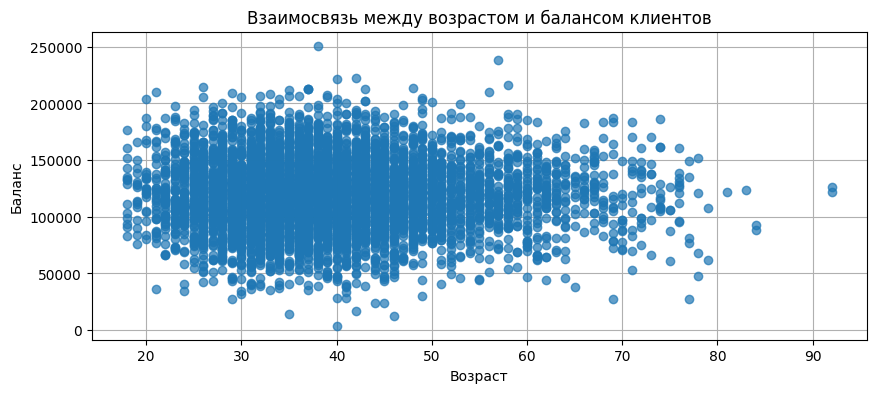

In [ ]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим линейный график
plt.plot(df['age'],
         df['balance'],
         marker='o', # Задаём стиль маркера
         linestyle='', # Делаем линии между точками невидимыми
         alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между возрастом и балансом клиентов')
plt.xlabel('Возраст')
plt.ylabel('Баланс')
plt.grid()

# Отображаем график
plt.show()

Посмотрим на связи с признаком лояльности клиента

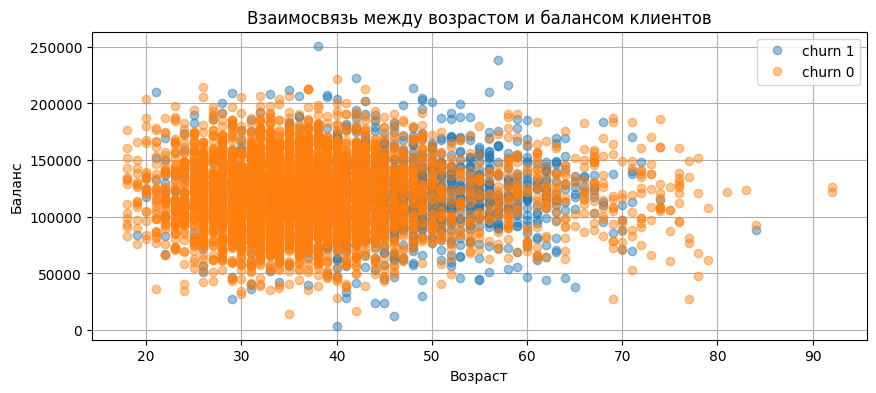

In [ ]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in df['churn'].unique():
    # Фильтруем данные по значению столбца churn
    plot_data = df.loc[df['churn'] == i]

    # Строим линейный график
    plt.plot(plot_data['age'],
             plot_data['balance'],
             marker='o', # Задаём стиль маркера
             linestyle='', # Делаем линии между точками невидимыми
             label=f'churn {i}',
             alpha=0.45)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между возрастом и балансом клиентов')
plt.xlabel('Возраст')
plt.ylabel('Баланс')
plt.legend()
plt.grid()

# Отображаем график
plt.show()

### Структура выводов

#### Общий вывод можно сформировать по такой структуре:
* Общий обзор проделанной работы. В этой части выводов укажите, какие данные вы изучили и что делали, какие задачи решали. Это поможет читателю понять объём аналитических исследований, а также представить общее направление работы.
* Ответы на исследовательские вопросы, или главные выводы. В этой части выводов дайте прямые и чёткие ответы на вопросы, поставленные перед началом анализа. Подкрепите их основными результатами, которые подтверждают или опровергают изначальные гипотезы. Здесь можно привести статистические данные, корреляции, зависимости и другие факторы, которые вы обнаружили.
* Рекомендации на основе анализа данных. Предложите практические рекомендации — они должны быть основаны на анализе и представлять собой действия, способные улучшить бизнес-процессы. В этом блоке можно также сделать акцент на возможных направлениях дальнейших исследований или будущих анализов. Такие исследования помогут усилить понимание текущих выводов или ответить на вопросы, которые не были рассмотрены в анализе.

<div style="background-color: #4400ff; color: white; padding: 15px; border-radius: 5px;"> 
 В ходе исследования проанализировали данные 10000 клиентов банка «Метанпром» из трёх городов. Данные включали персональную информацию клиентов и особенности использования услуг банка. Акцент исследования был на том, чтобы найти взаимосвязи между уходом клиентов и другими факторами. Среди них: возраст и город проживания клиента, текущий баланс и оценочная заработная плата, кредитный рейтинг и наличие кредитной карты, участие в программе лояльности, количество объектов недвижимости и продуктов банка.
* Исследовательский анализ данных позволил сформировать профиль клиента банка:
* Из 10000 проанализированных клиентов банка половина людей проживает в Ярославле, а остальная половина в Ростове Великом и Рыбинске в равном количестве.
* 54% клиентов — мужчины, а средний возраст клиентов составляет 39 лет.
* Как правило, клиенты банка пользуются 1–2 продуктами. Средний баланс составляет около 120 тыс. рублей, однако для 35% клиентов нет баланса. При этом 70% клиентов оформляют кредитные карты, а 51% участвует в программах лояльности.
* Ушедшие, или нелояльные, клиенты составляют 20% от всех клиентов банка.
На значение процента клиентов, ушедших в отток, положительно влияют несколько факторов: регион регистрации клиента, его возраст и пол, а также наличие баланса в банке, участие в программе лояльности и количество используемых продуктов.
Среди ушедших клиентов преобладают:
* люди из Ростова Великого — это 32% от всех клиентов региона;
* женщины — это 25% по сравнению с 16% для клиентов-мужчин;
* клиенты возрастом от 40 до 50 лет.
Ушедшие клиенты чаще других имеют баланс в банке, не участвуют в программах лояльности и пользуются одним банковским продуктом.
В качестве рекомендаций стоит обратить внимание на удержание клиентов возраста 40–50 лет. Им можно предложить более выгодные условия кредитования или разработать для них специальные банковские продукты и увеличить вовлечённость в программы лояльности.
Дополнительно можно провести более детальную сегментацию, чтобы выделить конкретные группы клиентов.
<div>